<a href="https://colab.research.google.com/github/shubhamunt/HPC_at_UTD/blob/main/Copy_of_TAIRI_Workshop_UnsupervisedML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAIRI Workshop: Unsupervised Learning
An interactive notebook for K-Means and PCA.

In [ ]:
# Setup
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from ipywidgets import interact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import plotly.express as px
plt.rcParams['figure.figsize'] = (6,4)

# Dataset

Breast Cancer Dataset

- Dataset source: sklearn.datasets.load_breast_cancer (Python) / mlbench::BreastCancer (R)

- Data size: 569

- Features: 30 numeric features describing tumor characteristics (e.g., radius, texture, perimeter, area, smoothness)

- Target: malignant or benign (used only for evaluation, not clustering)

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='Target')

# Print shape of X
print("Shape of X:")
print(X.shape)
print('*' * 50 + "\n")



Shape of X:
(569, 30)
**************************************************



In [ ]:
# Print column names including target
print("Columns names:")
print(X.columns)
print(y.name)
print('*' * 100 + "\n")


Columns names:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
Target
****************************************************************************************************



In [ ]:
# Print overview of X
print("X Overview:")
X.info()
print('*' * 100 + "\n")


X Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness err

In [ ]:
# Count missing values
missing_counts = X.isna().sum()
# Filter only features with missing values
missing_counts = missing_counts[missing_counts > 0]
print("Features with missing values:")
print(missing_counts)
print('*' * 100 + "\n")


Features with missing values:
Series([], dtype: int64)
****************************************************************************************************



In [ ]:
# Target distribution
print("Target distribution:")
print(y.value_counts())
print('*' * 100 + "\n")

Target distribution:
Target
1    357
0    212
Name: count, dtype: int64
****************************************************************************************************



In [ ]:
# scale dataset
X = data.data
y = data.target
feature_names = data.feature_names
X_scaled = StandardScaler().fit_transform(X)


# K-means Clustering


In [ ]:
# ==============================
# Interactive K-Means on Breast Cancer Data
# ==============================

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Define interactive plot
def show_clusters(k=2):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', marker='x', s=200, label='Centroids')
    plt.title(f"K-Means Clustering on Breast Cancer Data (K={k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.show()

# Interactive slider for K
interact(show_clusters, k=(1, 10))

interactive(children=(IntSlider(value=2, description='k', max=10, min=1), Output()), _dom_classes=('widget-int…

<function __main__.show_clusters(k=2)>

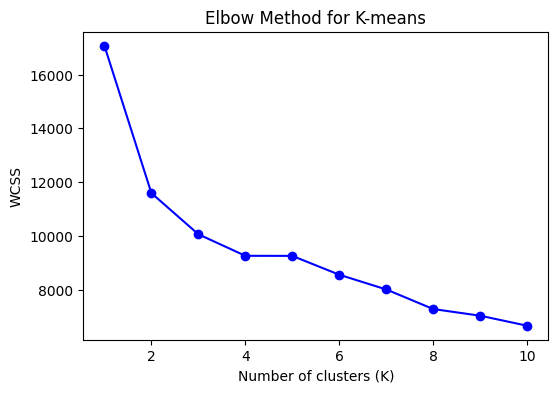

In [ ]:
# ==============================
# K-means Clustering
# ==============================

# Elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for K-means')
plt.show()



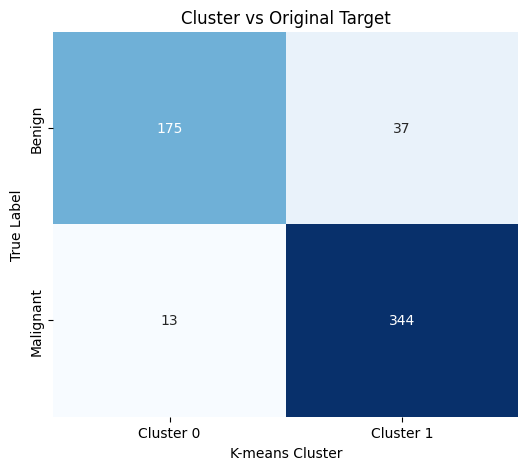

In [ ]:
# Fit final K-means (K=2)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Create confusion matrix
cm = confusion_matrix(y, clusters)

# Convert to DataFrame for plotting
cm_df = pd.DataFrame(cm,
                     index=['Benign', 'Malignant'],   # true labels
                     columns=['Cluster 0', 'Cluster 1'])  # clusters

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.ylabel('True Label')
plt.xlabel('K-means Cluster')
plt.title('Cluster vs Original Target')
plt.show()

# Principal Component Analysis (PCA)

In [ ]:
# Interactive function
def show_pca_components(n=2):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    explained = np.sum(pca.explained_variance_ratio_) * 100

    plt.figure(figsize=(6,5))
    if n == 2:
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
        plt.xlabel("PC1"); plt.ylabel("PC2")
    elif n == 3:
        from mpl_toolkits.mplot3d import Axes3D
        ax = plt.figure(figsize=(7,6)).add_subplot(projection='3d')
        ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=y, cmap='coolwarm', alpha=0.7)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    else:
        plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, 'o-')
        plt.xlabel("Number of Components")
        plt.ylabel("Cumulative % Variance Explained")
    plt.title(f"PCA with {n} components (explains {explained:.1f}% variance)")
    plt.show()

interact(show_pca_components, n=(1,10))

interactive(children=(IntSlider(value=2, description='n', max=10, min=1), Output()), _dom_classes=('widget-int…

<function __main__.show_pca_components(n=2)>

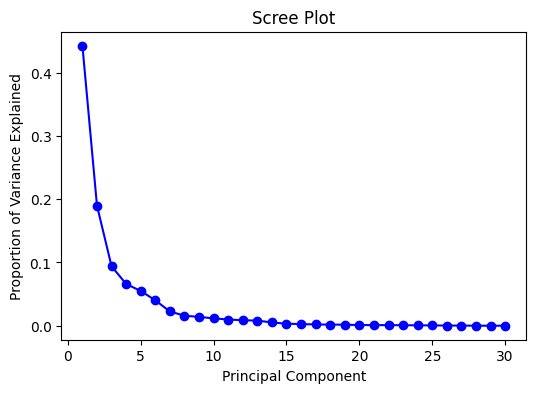

In [ ]:
# ==============================
# PCA - Python
# ==============================

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


# Scree plot
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.show()

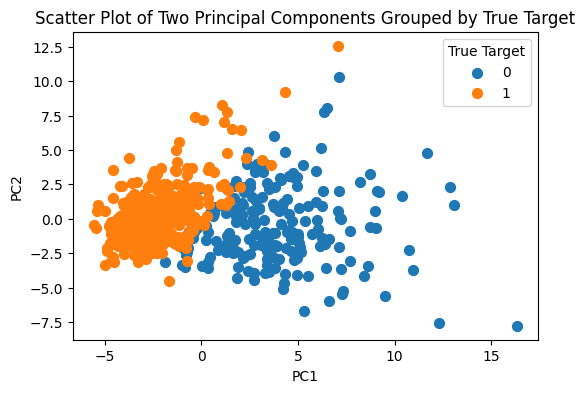

In [ ]:
plt.figure(figsize=(6,4))
for label in np.unique(y):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        s=50,
        label=f'{label}'
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot of Two Principal Components Grouped by True Target')
plt.legend(title='True Target')
plt.show()

# R

## Run R code in Python

In [ ]:
# Installs the rpy2 package, which acts as a bridge between Python and R.
!pip install rpy2
# Loads the R extension
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("RCurl")

## Load the Dataset

In [ ]:
%%R
install.packages("RCurl")
library(RCurl)

# Load the data
UCI_data_URL <- getURL('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data')
names <- c('id_number', 'diagnosis', 'radius_mean',
           'texture_mean', 'perimeter_mean', 'area_mean',
           'smoothness_mean', 'compactness_mean',
           'concavity_mean','concave_points_mean',
           'symmetry_mean', 'fractal_dimension_mean',
           'radius_se', 'texture_se', 'perimeter_se',
           'area_se', 'smoothness_se', 'compactness_se',
           'concavity_se', 'concave_points_se',
           'symmetry_se', 'fractal_dimension_se',
           'radius_worst', 'texture_worst',
           'perimeter_worst', 'area_worst',
           'smoothness_worst', 'compactness_worst',
           'concavity_worst', 'concave_points_worst',
           'symmetry_worst', 'fractal_dimension_worst')

breast_cancer <- read.table(textConnection(UCI_data_URL), sep = ',', col.names = names)

# Remove the id_number column
breast_cancer$id_number <- NULL

# Dimensions of data
cat("Dimensions of data:\n")
print(dim(breast_cancer))
cat(strrep("*", 50), "\n\n")

# Column names (features + target)
cat("Column names:\n")
print(colnames(breast_cancer))
cat(strrep("*", 100), "\n\n")

# Structure of data (similar to Python's info)
cat("Data structure:\n")
print(str(breast_cancer))
cat(strrep("*", 100), "\n\n")

# Count missing values per feature
missing_counts <- sapply(breast_cancer, function(x) sum(is.na(x)))
missing_counts <- missing_counts[missing_counts > 0]
cat("Features with missing values:\n")
print(missing_counts)
cat(strrep("*", 100), "\n\n")

# Target distribution
cat("Target distribution:\n")
print(table(breast_cancer$diagnosis))
cat(strrep("*", 100), "\n\n")


## K-means Clustering

In [ ]:
%%R
# ==============================
# K-means Clustering
# ==============================
library(tidyverse)
library(cluster)

# Prepare data
X <- breast_cancer %>% select(-diagnosis)
X_scaled <- scale(X)
y <- breast_cancer$diagnosis

# Elbow method manually
wcss <- numeric()
for(k in 1:10){
  km <- kmeans(X_scaled, centers=k, nstart=25)
  wcss[k] <- km$tot.withinss
}

# Elbow plot
elbow_df <- data.frame(K = 1:10, WCSS = wcss)
elbow_plot <- ggplot(elbow_df, aes(x = K, y = WCSS)) +
  geom_point(size=3, color="blue") +
  geom_line(color="blue") +
  scale_x_continuous(breaks = 1:10) +
  labs(title = "Elbow Method for K-means",
       x = "Number of clusters (K)",
       y = "Total within-cluster sum of squares (WCSS)") +
  theme_minimal()

print(elbow_plot)

In [ ]:
%%R
# Fit final K-means (K=2)
set.seed(42)
kmeans_res <- kmeans(X_scaled, centers=2, nstart=25)

# Create confusion matrix
cm <- table(Cluster = kmeans_res$cluster, TrueLabel = y)

# Convert table to data frame for ggplot
cm_df <- as.data.frame(cm)
colnames(cm_df) <- c("Cluster", "TrueLabel", "Count")

# Plot heatmap using ggplot2
ggplot(cm_df, aes(x = Cluster, y = TrueLabel, fill = Count)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Count), size = 6) +
  scale_fill_gradient(low = "lightblue", high = "blue", guide = "none") +  # no color bar
  labs(title = "Cluster vs Original Target",
       x = "K-means Cluster",
       y = "True Label") +
  theme_minimal() +
  theme(
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 16, hjust = 0.5)
  )

## Principal Component Analysis (PCA)

In [ ]:
%%R
library(ggplot2)

# PCA
pca_res <- prcomp(X_scaled, scale = FALSE)

# Variance explained
var_explained <- pca_res$sdev^2
var_explained_percent <- var_explained / sum(var_explained) * 100

# Create data frame for scree plot
scree_df <- data.frame(
  PC = factor(paste0("PC", 1:length(var_explained_percent)),
              levels = paste0("PC", 1:length(var_explained_percent))),
  Variance = var_explained_percent
)

# Scree plot with ggplot
ggplot(scree_df, aes(x = PC, y = Variance)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = round(Variance, 1)), vjust = -0.5, size = 3) +
  labs(title = "Scree Plot",
       x = "Principal Components",
       y = "Variance Explained (%)") +
  ylim(0, 50) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
